# E10 Muon Variant And Normalization Ablation

### Problem

This notebook asks which part of Muon explains its behavior: polar matrix geometry, approximation quality, or simple gradient normalization. It reuses representative Matrix Sensing and Matrix Factorization settings from the geometry diagnostics.

For Matrix Sensing settings,

$$y_i=\langle A_i,X^\star\rangle+\xi_i,\qquad f(X)=\frac{1}{2m}\sum_{i=1}^{m}(\langle A_i,X\rangle-y_i)^2,$$

with Gaussian measurements, $m=\alpha dr$, and direct Gaussian initialization $X_0=10^{-2}G_0$. For Matrix Factorization settings,

$$\widehat X=W_1W_2\cdots W_{10},\qquad g(W_{1:10})=\frac{1}{2d^2}\lVert W_1W_2\cdots W_{10}-X^\star\rVert_F^2,$$

with Gaussian target construction $X^\star=U\operatorname{diag}(s)V^\top$, Gaussian endpoint initialization, and identity middle factors.

The optimizer variants compare several update geometries. Exact Muon replaces a matrix gradient $G=P\Sigma Q^\top$ by its polar direction $PQ^\top$. Newton-Schulz variants approximate this polar direction using different iteration counts. Truncated and randomized variants approximate the same spectral direction with lower-rank or randomized computations. Normalized SGD baselines divide the gradient by Frobenius or spectral norm. The experiment records both accuracy and per-step time, so the plots distinguish better geometry from extra compute.


## Implementation Details: Skip Unless Modifying The Experiment

The code below is visible for reproducibility. A reader can skip it unless changing the grid, optimizer definitions, stopping rule, diagnostics, or plotting calls.

In [1]:
import math
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.11.0


### Parameters And Runs


In [2]:
NOTEBOOK_ID = "E10 Muon variants"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = [
    "Muon", "Muon-Exact", "Muon-NS-1", "Muon-NS-10", "Muon-Truncated", "Muon-RandSVD",
    "Shampoo", "Adam", "SGD", "NormalizedSGD", "SpectralNormSGD", "LayerwiseNormalizedSGD",
]
SEEDS = list(range(10))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 600

BASE_SPEC = dict(
    d=60,
    rank=5,
    lr=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    diagnostic_every=1 if SMOKE_TEST else 20,
    early_stop=True,
    early_stop_min_steps=100,
    early_stop_patience=20,
    early_stop_min_delta=1e-4,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
SETTINGS = [
    dict(setting="MS-easy", problem="MatrixSensing", spectrum="hard-cutoff", kappa=1.0, m_multiplier=8, noise=0.0, init_scale=0.01),
    dict(setting="MS-hard", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=6, noise=0.0, init_scale=0.01),
    dict(setting="MS-undersampled", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=1, noise=0.0, init_scale=0.01),
    dict(setting="MS-noisy", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=4, noise=0.03, init_scale=0.01),
    dict(setting="MF-standard", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=0.01, right_scale=0.01),
    dict(setting="MF-tiny", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1e-4),
    dict(setting="MF-overparam", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=20, left_scale=0.01, right_scale=0.01),
    dict(setting="MF-imbalanced", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1.0),
]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **setting, "algo": algo, "seed": seed}
    for setting in SETTINGS
    for algo in ALGOS
    for seed in SEEDS
])
runs.insert(0, "run_id", range(len(runs)))

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}, diagnostic_every={BASE_SPEC['diagnostic_every']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=600, diagnostic_every=20
runs=960, max_total_steps=576000


,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,spectrum,kappa,m_multiplier,noise,init_scale,algo,seed,factor_rank,left_scale,right_scale
0,0,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,0,NaN,NaN,NaN
1,1,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,1,NaN,NaN,NaN
2,2,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,2,NaN,NaN,NaN
3,3,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,3,NaN,NaN,NaN
4,4,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,955,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,LayerwiseNormalizedSGD,5,5.0,0.0001,1.0
956,956,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,LayerwiseNormalizedSGD,6,5.0,0.0001,1.0
957,957,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,LayerwiseNormalizedSGD,7,5.0,0.0001,1.0
958,958,60,5,0.01,600,20,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,LayerwiseNormalizedSGD,8,5.0,0.0001,1.0


### Pseudocode

```text
for each representative setting, Muon variant or normalization baseline, seed:
    initialize the Matrix Sensing or Matrix Factorization problem
    define step(state): loss -> backward -> clone gradient -> optimizer.step -> actual update
    record recovery, cost, descent alignment, and update rank every diagnostic interval
compare accuracy-cost, Muon approximation quality, and normalization baselines
```


### Worker Definition


In [ ]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="randsvd", rank=rank, oversample=5, power_iters=1)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="spectral")
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    raise ValueError(f"unknown algo: {algo}")


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)


def single_run(run):
    run = dict(run)
    d = int(run["d"])
    rank = int(run["rank"])
    seed = int(run["seed"])
    iters = int(run["iters"])
    diagnostic_every = int(run["diagnostic_every"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    if run["problem"] == "MatrixSensing":
        problem = problems.MatrixSensing.make_matrix_sensing_problem(
            d,
            rank,
            noise=float(run["noise"]),
            dist="normal",
            spectrum=run["spectrum"],
            kappa=float(run["kappa"]),
            seed=seed,
            device=device,
            dtype=dtype,
            m_multiplier=float(run["m_multiplier"]),
        )
        x = torch.nn.Parameter(problems.MatrixConstruction.randn((d, d), seed + 3000, device, dtype) * float(run["init_scale"]))
        params = [x]
        estimate = lambda: x.detach()
        objective = lambda: problem.loss(x)
        factor_metrics = lambda: {}
    else:
        factor_rank = int(run["factor_rank"])
        problem = problems.MatrixFactorization.make_matrix_factorization_problem(
            d,
            rank,
            spectrum=run["spectrum"],
            kappa=float(run["kappa"]),
            seed=seed,
            device=device,
            dtype=dtype,
            factor_rank=factor_rank,
            num_factors=int(run.get("num_factors", 10)),
        )
        factor_inits = problems.MatrixFactorization.initialize_factor_chain(
            d, factor_rank, seed=seed + 3000, device=device, dtype=dtype,
            num_factors=int(run.get("num_factors", 10)),
            left_scale=float(run["left_scale"]), right_scale=float(run["right_scale"]),
        )
        factors = [torch.nn.Parameter(factor) for factor in factor_inits]
        params = factors
        estimate = lambda: problem.estimate(*factors).detach()
        objective = lambda: problem.loss(*factors)
        factor_metrics = lambda: {
            "left_norm": float(factors[0].detach().norm().cpu()),
            "right_norm": float(factors[-1].detach().norm().cpu()),
            "factor_norm_mean": float(np.mean([factor.detach().norm().cpu().item() for factor in factors])),
            "balancedness": util.diagnostics.balancedness(*factors),
        }

    optimizer = make_optimizer(run["algo"], params, float(run["lr"]), rank)
    initial_loss = float(objective().detach().cpu())
    best_loss = None
    early_stop_wait = 0
    rows = []
    start_time = time.perf_counter()

    for step_index in range(1, iters + 1):
        optimizer.zero_grad(set_to_none=True)
        loss = objective()
        loss.backward()
        gradients = [param.grad.detach().clone() for param in params]
        before = [param.detach().clone() for param in params]
        optimizer.step()
        updates = [param.detach() - old for param, old in zip(params, before)]
        loss_value = float(loss.detach().cpu())

        if best_loss is None:
            best_loss = loss_value
        elif best_loss - loss_value >= early_stop_min_delta:
            best_loss = loss_value
            early_stop_wait = 0
        else:
            early_stop_wait += 1

        stop_reason = ""
        if not math.isfinite(loss_value) or loss_value > max(1e6, 1e6 * max(initial_loss, 1e-12)):
            stop_reason = "diverged"
        elif early_stop and step_index >= early_stop_min_steps and early_stop_wait >= early_stop_patience:
            stop_reason = "early_stop_patience"
        elif step_index == iters:
            stop_reason = "max_iters"

        should_record = step_index == 1 or step_index % diagnostic_every == 0 or bool(stop_reason)
        if should_record:
            x_hat = estimate()
            grad_stats = util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad")
            update_stats = util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update")
            row = {
                **run,
                "initial_loss": initial_loss,
                "step": step_index,
                "loss": loss_value,
                "best_loss": best_loss,
                "early_stop_wait": early_stop_wait,
                "elapsed_s": time.perf_counter() - start_time,
                "stop_reason": stop_reason,
                "relative_matrix_error": util.diagnostics.relative_matrix_error(x_hat, problem.target),
                "solution_effective_rank": util.diagnostics.effective_rank(x_hat),
                "top_sv_relative_error": util.diagnostics.top_singular_value_error(x_hat, problem.target, k=rank),
                "grad_update_cosine": util.diagnostics.descent_alignment(gradients, updates),
                "relative_step_size": util.diagnostics.relative_step_size(before, updates),
                "update_to_grad_norm_ratio": update_stats["update_fro_norm"] / max(grad_stats["grad_fro_norm"], 1e-12),
                **grad_stats,
                **update_stats,
                **factor_metrics(),
            }
            target_sv = torch.linalg.svdvals(problem.target.detach())[:rank]
            solution_sv = torch.linalg.svdvals(x_hat.detach())[:rank]
            for idx in range(rank):
                row[f"target_sv_{idx + 1}"] = float(target_sv[idx].cpu()) if idx < len(target_sv) else 0.0
                row[f"solution_sv_{idx + 1}"] = float(solution_sv[idx].cpu()) if idx < len(solution_sv) else 0.0
            rows.append(row)
        if stop_reason:
            break

    return pd.DataFrame(rows)


## Results

The execute cell materializes the long per-step `runs` table. The saved outputs below are the experimental results to inspect.

In [4]:
runs = util.run_experiments(
    runs,
    single_run,
    num_workers=NUM_WORKERS,
    backend=JOBLIB_BACKEND,
    algo_order=ALGOS,
    sort_columns=("run_id", "step"),
    desc=NOTEBOOK_ID,
)
IPython.display.display(runs)


E10 Muon variants:   0%|          | 0/960 [00:00<?, ?run/s]

E10 Muon variants:   0%|          | 1/960 [00:29<7:49:20, 29.36s/run]

E10 Muon variants:   1%|          | 6/960 [00:30<1:00:09,  3.78s/run]

E10 Muon variants:   1%|          | 11/960 [00:33<32:31,  2.06s/run] 

E10 Muon variants:   1%|▏         | 14/960 [00:35<24:24,  1.55s/run]

...

E10 Muon variants:  56%|█████▌    | 535/960 [05:40<00:20, 21.20run/s]

E10 Muon variants:  70%|██████▉   | 669/960 [05:41<00:05, 48.78run/s]

E10 Muon variants:  83%|████████▎ | 801/960 [05:42<00:02, 70.35run/s]

E10 Muon variants: 100%|██████████| 960/960 [05:43<00:00,  2.80run/s]

,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,solution_sv_2,target_sv_3,solution_sv_3,target_sv_4,solution_sv_4,target_sv_5,solution_sv_5,left_norm,right_norm,balancedness
0,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.138572,1.0,0.136101,1.0,0.127884,1.0,0.125979,NaN,NaN,NaN
1,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.263448,1.0,0.260810,1.0,0.252213,1.0,0.242799,NaN,NaN,NaN
2,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.440691,1.0,0.438002,1.0,0.422635,1.0,0.412300,NaN,NaN,NaN
3,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.572551,1.0,0.550864,1.0,0.541050,1.0,0.531852,NaN,NaN,NaN
4,0,60,5,0.01,600,20,True,100,20,0.0001,...,0.607143,1.0,0.599684,1.0,0.574055,1.0,0.547868,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6325,959,60,5,0.01,600,20,True,100,20,0.0001,...,0.473196,1.0,0.271088,1.0,0.098729,1.0,0.010459,0.111053,17.005950,0.999905
6326,959,60,5,0.01,600,20,True,100,20,0.0001,...,0.535042,1.0,0.315716,1.0,0.118417,1.0,0.013822,0.126057,17.064008,0.999879
6327,959,60,5,0.01,600,20,True,100,20,0.0001,...,0.649768,1.0,0.481088,1.0,0.172657,1.0,0.020145,0.158202,17.161468,0.999819
6328,959,60,5,0.01,600,20,True,100,20,0.0001,...,0.689815,1.0,0.605251,1.0,0.219827,1.0,0.027947,0.180084,17.265099,0.999772


### Result Tables


In [5]:
ordered_runs = runs.sort_values(["run_id", "step"])
dynamic_columns = [
    "step", "initial_loss", "loss", "best_loss", "early_stop_wait", "elapsed_s", "stop_reason",
    "relative_matrix_error", "solution_effective_rank", "top_sv_relative_error", "grad_update_cosine",
    "relative_step_size", "update_to_grad_norm_ratio", "grad_fro_norm", "grad_op_norm",
    "grad_effective_rank", "grad_stable_rank", "update_fro_norm", "update_op_norm",
    "update_effective_rank", "update_stable_rank", "left_norm", "right_norm", "balancedness",
]
dynamic_columns += [f"target_sv_{idx}" for idx in range(1, 8)] + [f"solution_sv_{idx}" for idx in range(1, 8)]
run_summary = ordered_runs.groupby("run_id", as_index=False).first().drop(columns=dynamic_columns, errors="ignore")
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        initial_loss=("initial_loss", "first"),
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        relative_matrix_error=("relative_matrix_error", "last"),
        top_sv_relative_error=("top_sv_relative_error", "last"),
        solution_effective_rank=("solution_effective_rank", "last"),
        grad_update_cosine=("grad_update_cosine", "last"),
        update_effective_rank=("update_effective_rank", "last"),
        relative_step_size=("relative_step_size", "last"),
        actual_steps=("step", "last"),
        time_s=("elapsed_s", "last"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["time_per_step"] = run_summary["time_s"] / run_summary["actual_steps"].clip(lower=1)
run_summary["stopped_early"] = run_summary["stop_reason"].eq("early_stop_patience")
run_summary["diverged"] = run_summary["stop_reason"].eq("diverged")
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["algo", "setting", "seed"]).reset_index(drop=True)
run_summary["algo"] = run_summary["algo"].astype(str)
IPython.display.display(run_summary)


,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,solution_effective_rank,grad_update_cosine,update_effective_rank,relative_step_size,actual_steps,time_s,stop_reason,time_per_step,stopped_early,diverged
0,840,60,5,0.01,600,20,True,100,20,0.0001,...,4.688325,0.250955,4.918192,0.005665,115,0.041591,early_stop_patience,0.000362,True,False
1,841,60,5,0.01,600,20,True,100,20,0.0001,...,4.721590,0.185309,4.946821,0.007100,100,0.029658,early_stop_patience,0.000297,True,False
2,842,60,5,0.01,600,20,True,100,20,0.0001,...,4.736903,0.268777,4.895366,0.006345,100,0.034733,early_stop_patience,0.000347,True,False
3,843,60,5,0.01,600,20,True,100,20,0.0001,...,4.812844,-0.026698,4.927888,0.006486,105,0.076337,early_stop_patience,0.000727,True,False
4,844,60,5,0.01,600,20,True,100,20,0.0001,...,4.801488,0.158759,4.943902,0.007120,109,0.033473,early_stop_patience,0.000307,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,355,60,5,0.01,600,20,True,100,20,0.0001,...,48.163734,0.924281,48.721648,0.009674,100,0.155651,early_stop_patience,0.001557,True,False
956,356,60,5,0.01,600,20,True,100,20,0.0001,...,47.627670,0.477562,48.277478,0.006495,100,0.156872,early_stop_patience,0.001569,True,False
957,357,60,5,0.01,600,20,True,100,20,0.0001,...,47.827030,0.941665,47.881868,0.008790,113,0.170671,early_stop_patience,0.001510,True,False
958,358,60,5,0.01,600,20,True,100,20,0.0001,...,47.910098,0.957463,48.484315,0.008308,100,0.119915,early_stop_patience,0.001199,True,False


### Accuracy-Cost Scatter

The Problem cell asks whether Muon behavior comes from polar geometry, approximation quality, or normalization; this plot first separates accuracy from per-step cost for all variants.

Each scatter plot fixes one benchmark setting. A point is one optimizer or optimizer variant. The horizontal coordinate is seed-median time per step, the vertical coordinate is seed-median recovery error $e(\widehat X)$ on a log scale, and color is the method identity. The lower-left region is best: lower error and lower per-step cost. This plot separates algorithmic accuracy from implementation cost.

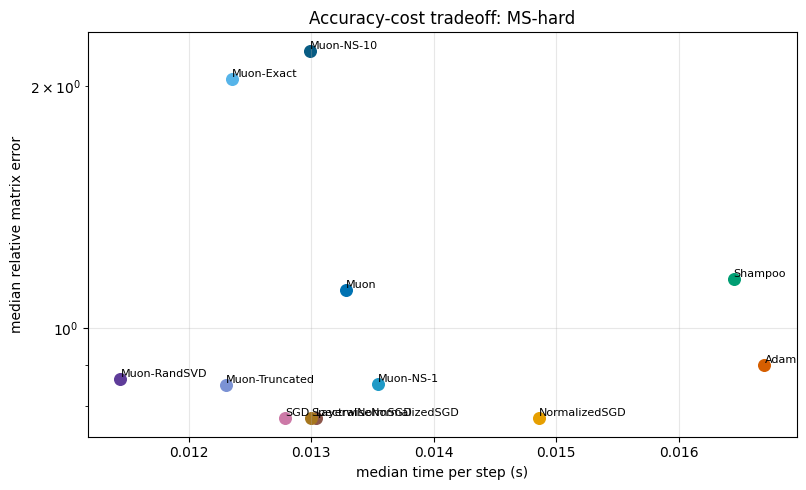

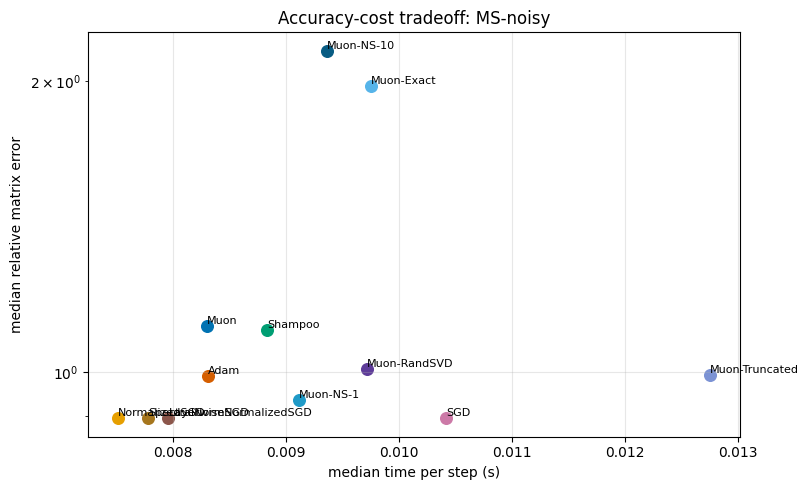

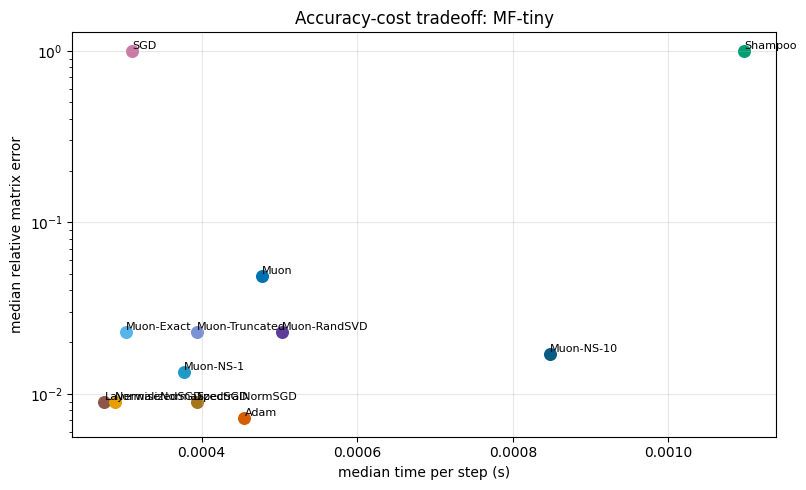

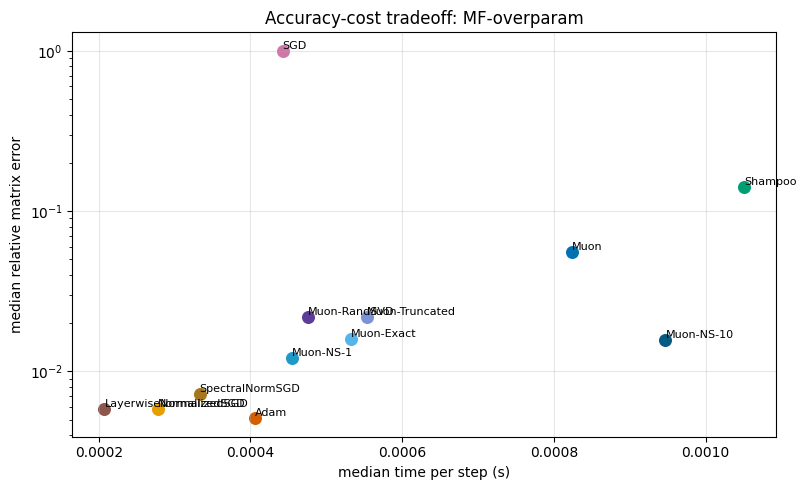

In [6]:
for setting in ["MS-hard", "MS-noisy", "MF-tiny", "MF-overparam"]:
    summary = run_summary[run_summary["setting"] == setting].groupby("algo", as_index=False, observed=True).agg(
        median_error=("relative_matrix_error", "median"),
        median_time_per_step=("time_per_step", "median"),
    )
    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    for _, row in summary.iterrows():
        ax.scatter(row["median_time_per_step"], row["median_error"], color=plotting.algorithm_color(row["algo"]), s=70)
        ax.text(row["median_time_per_step"], row["median_error"], row["algo"], fontsize=8, ha="left", va="bottom")
    ax.set_title(f"Accuracy-cost tradeoff: {setting}")
    ax.set_xlabel("median time per step (s)")
    ax.set_ylabel("median relative matrix error")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    show_figure(fig)


### Muon Approximation Quality

This plot focuses on the approximation-quality part of the Problem cell's question by comparing only Muon-family polar approximations.

Each bar plot fixes one setting and compares only Muon-family variants. The horizontal axis is the approximation variant, such as fewer Newton-Schulz steps, exact polar update, truncation, or randomized SVD. The vertical axis is seed-median recovery error on a log scale. This plot asks how much of Muon's behavior depends on accurately approximating its polar-style update geometry.

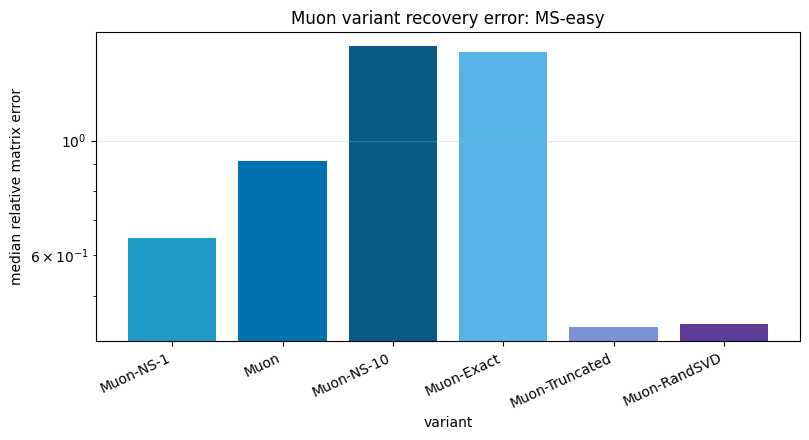

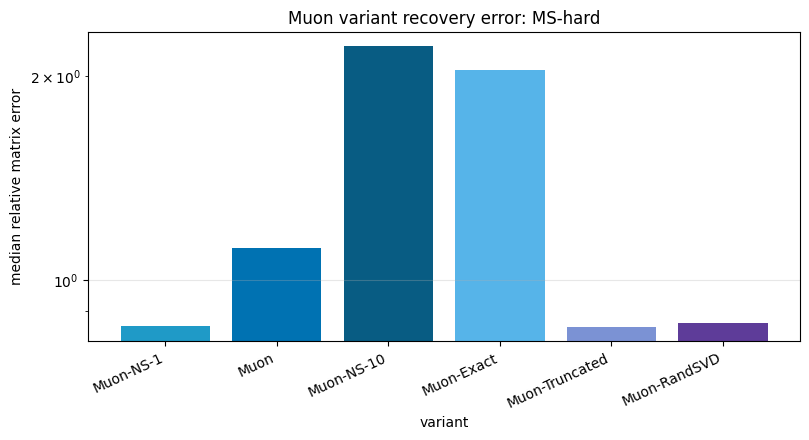

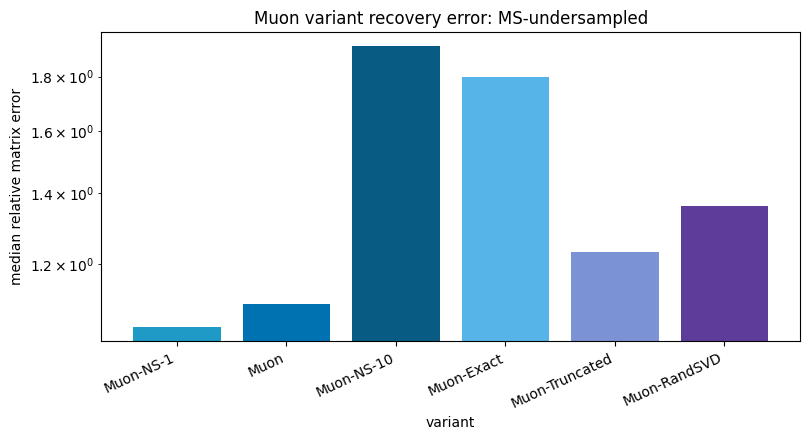

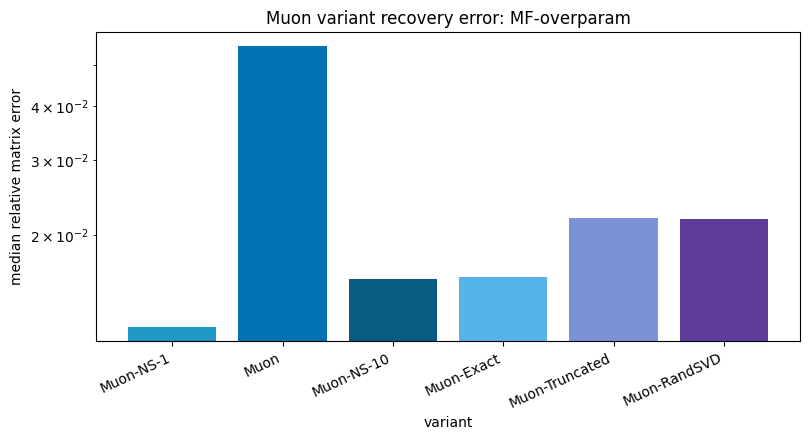

In [7]:
MUON_VARIANTS = ["Muon-NS-1", "Muon", "Muon-NS-10", "Muon-Exact", "Muon-Truncated", "Muon-RandSVD"]
for setting in ["MS-easy", "MS-hard", "MS-undersampled", "MF-overparam"]:
    sub = run_summary[(run_summary["setting"] == setting) & (run_summary["algo"].isin(MUON_VARIANTS))]
    summary = sub.groupby("algo", observed=True)["relative_matrix_error"].median().reindex(MUON_VARIANTS)
    fig, ax = plt.subplots(figsize=(8.2, 4.5))
    ax.bar(summary.index, summary.values, color=[plotting.algorithm_color(str(algo)) for algo in summary.index])
    ax.set_title(f"Muon variant recovery error: {setting}")
    ax.set_xlabel("variant")
    ax.set_ylabel("median relative matrix error")
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3)
    for tick in ax.get_xticklabels():
        tick.set_rotation(25)
        tick.set_ha("right")
    fig.tight_layout()
    show_figure(fig)


### Normalization Baseline Comparison

This plot focuses on the normalization part of the Problem cell's question by comparing Muon against gradient-normalization baselines.

Each bar plot fixes one setting and compares SGD, several normalized-SGD baselines, Muon, and Muon-Exact. The horizontal axis is method and the vertical axis is seed-median recovery error on a log scale. This is not a runtime plot; it asks whether simple gradient normalization can reproduce the accuracy of Muon-style matrix geometry.

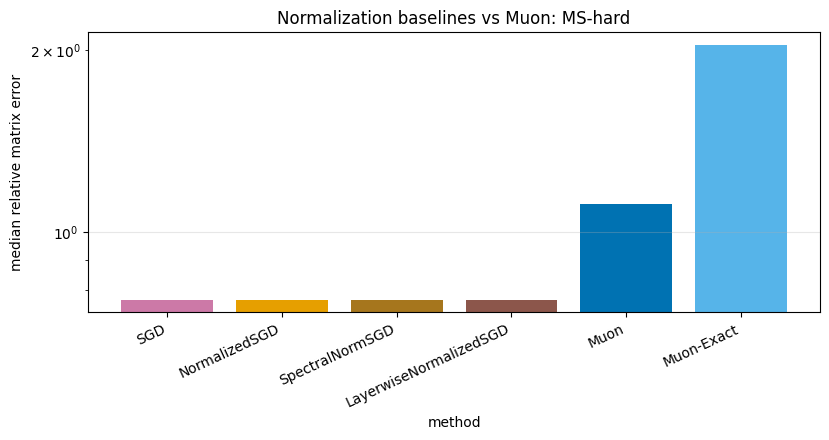

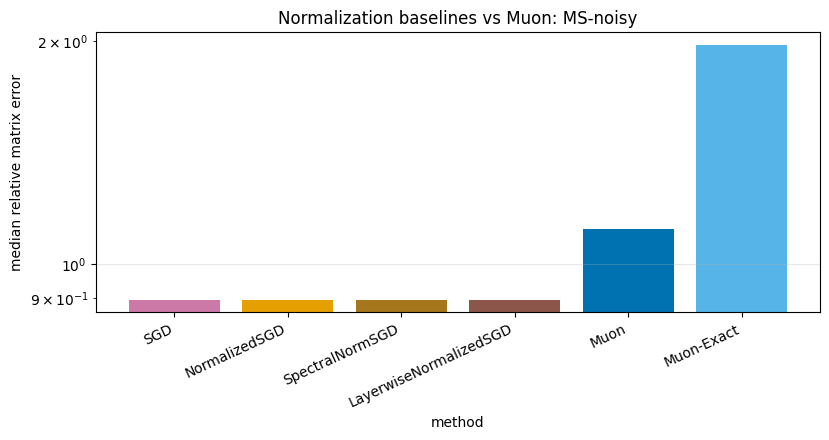

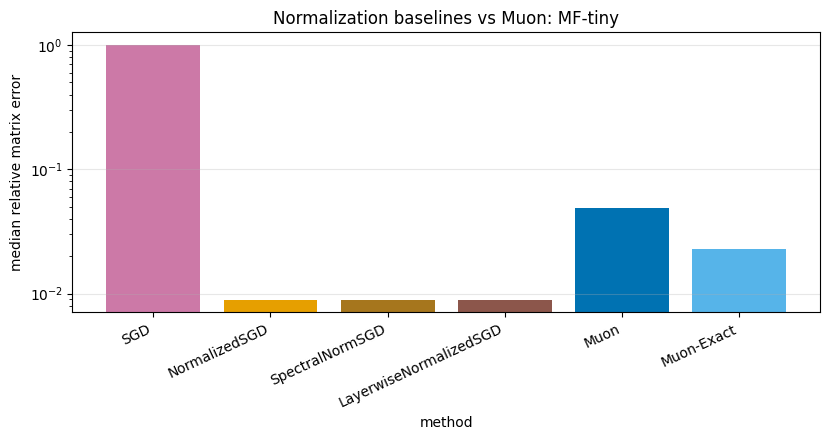

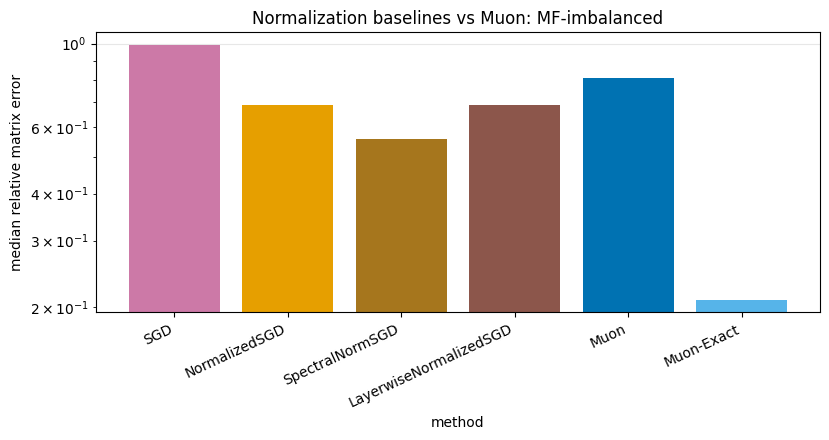

In [8]:
NORMALIZATION_SET = ["SGD", "NormalizedSGD", "SpectralNormSGD", "LayerwiseNormalizedSGD", "Muon", "Muon-Exact"]
for setting in ["MS-hard", "MS-noisy", "MF-tiny", "MF-imbalanced"]:
    sub = run_summary[(run_summary["setting"] == setting) & (run_summary["algo"].isin(NORMALIZATION_SET))]
    summary = sub.groupby("algo", observed=True)["relative_matrix_error"].median().reindex(NORMALIZATION_SET)
    fig, ax = plt.subplots(figsize=(8.4, 4.5))
    ax.bar(summary.index, summary.values, color=[plotting.algorithm_color(str(algo)) for algo in summary.index])
    ax.set_title(f"Normalization baselines vs Muon: {setting}")
    ax.set_xlabel("method")
    ax.set_ylabel("median relative matrix error")
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3)
    for tick in ax.get_xticklabels():
        tick.set_rotation(25)
        tick.set_ha("right")
    fig.tight_layout()
    show_figure(fig)


### Gradient-Update Cosine

The Problem cell contrasts update geometries; this plot shows how closely each variant aligns with steepest descent.

Each generated figure fixes one setting and compares update directions over time. The horizontal axis is diagnostic step $t$, color is optimizer variant, and the vertical value is seed-median $c_t=\langle -G_t,U_t\rangle/(\lVert G_t\rVert_F\lVert U_t\rVert_F)$. The zero line marks orthogonality to steepest descent. This plot helps distinguish variants that are accurate because they behave like descent from variants that take more geometrically transformed directions.

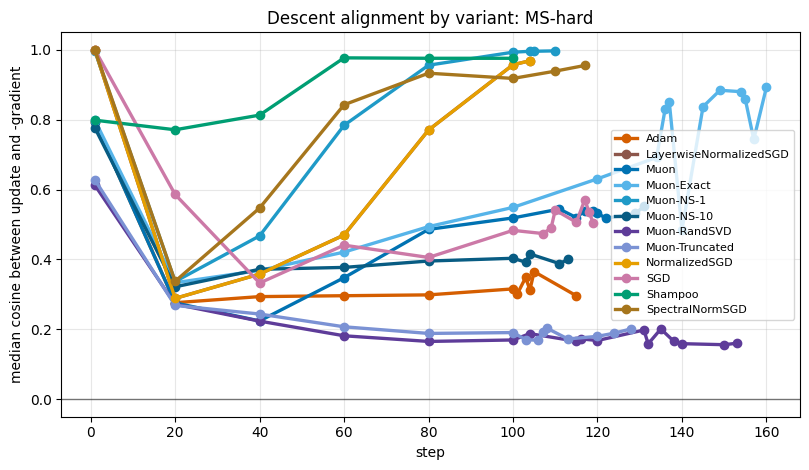

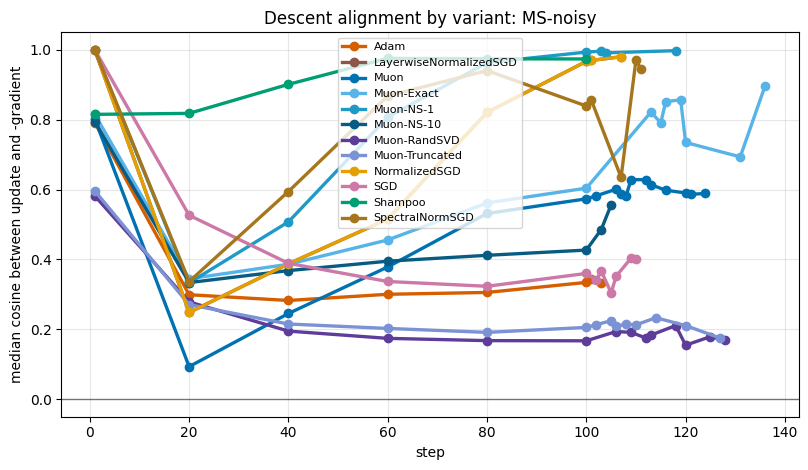

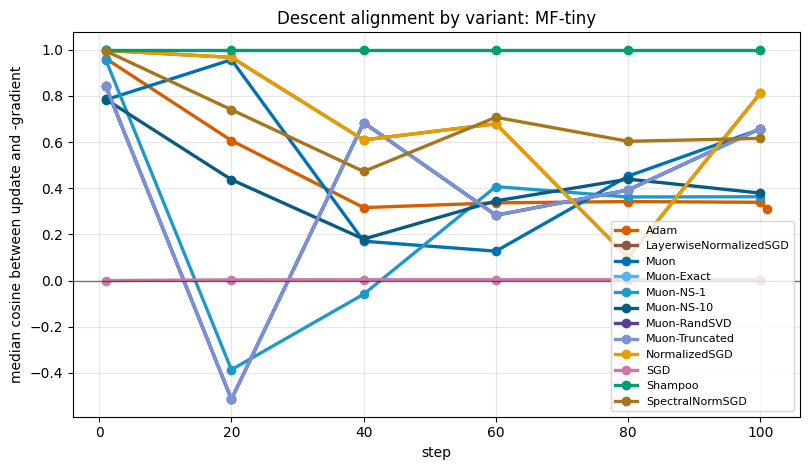

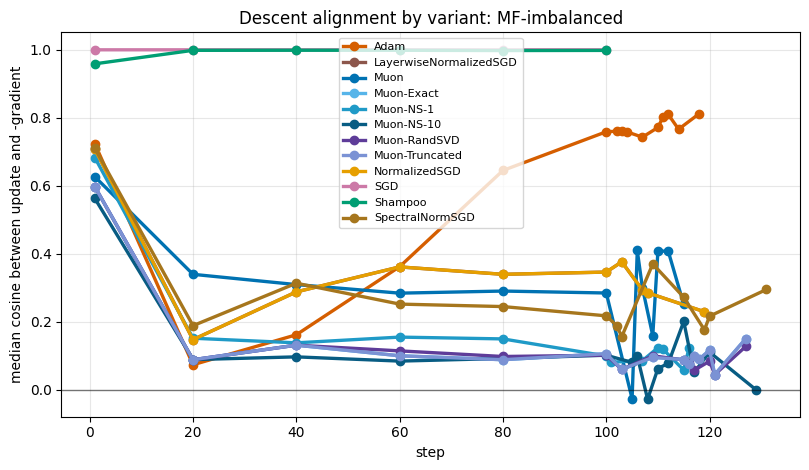

In [9]:
for setting in ["MS-hard", "MS-noisy", "MF-tiny", "MF-imbalanced"]:
    fig, ax = plotting.plot_metric_lines(
        runs[runs["setting"] == setting],
        x="step",
        metric="grad_update_cosine",
        title=f"Descent alignment by variant: {setting}",
        ylabel="median cosine between update and -gradient",
    )
    ax.axhline(0, color="black", linewidth=1, alpha=0.5)
    show_figure(fig)


### Update Effective Rank

The Problem cell emphasizes matrix update geometry; this plot checks whether variants produce different spectral ranks in $U_t$.

Each generated figure fixes one setting. The horizontal axis is step $t$, color is optimizer variant, and the vertical value is seed-median effective rank of the update $U_t$. Since Muon variants differ mainly in how they approximate or alter the matrix update, this plot shows whether those variants produce low-rank, high-rank, or spectrally flattened updates.

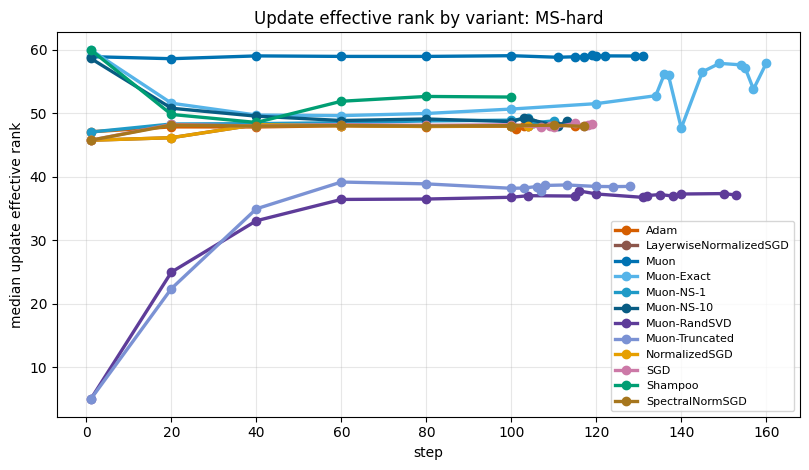

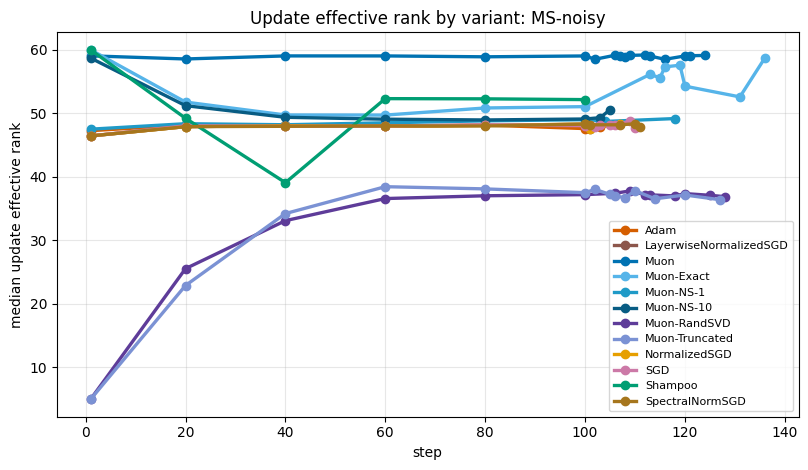

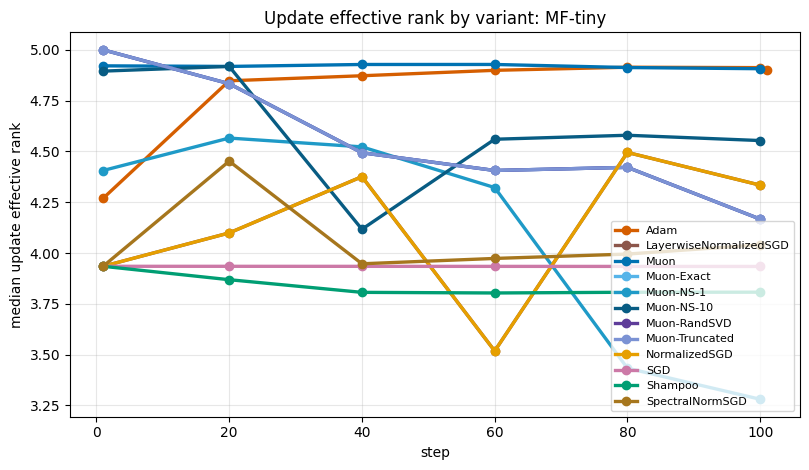

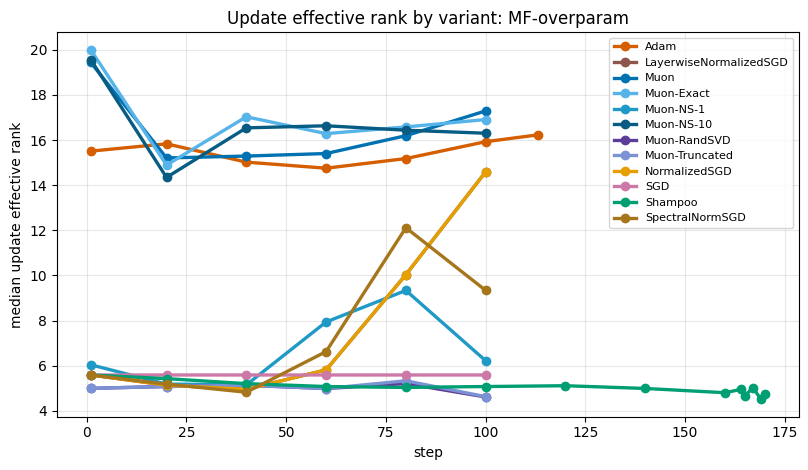

In [10]:
for setting in ["MS-hard", "MS-noisy", "MF-tiny", "MF-overparam"]:
    fig, ax = plotting.plot_metric_lines(
        runs[runs["setting"] == setting],
        x="step",
        metric="update_effective_rank",
        title=f"Update effective rank by variant: {setting}",
        ylabel="median update effective rank",
    )
    show_figure(fig)


### Representative Loss Curves

These curves show the optimization dynamics behind the endpoint accuracy comparisons in the Problem-cell variant study.

These figures show two representative settings with all methods overlaid. The horizontal axis is step $t$, the vertical axis is seed-median training loss, and color is optimizer or variant. Because this plot is intentionally crowded, use it for qualitative dynamics and then rely on the accuracy-cost and bar plots above for cleaner endpoint comparisons.

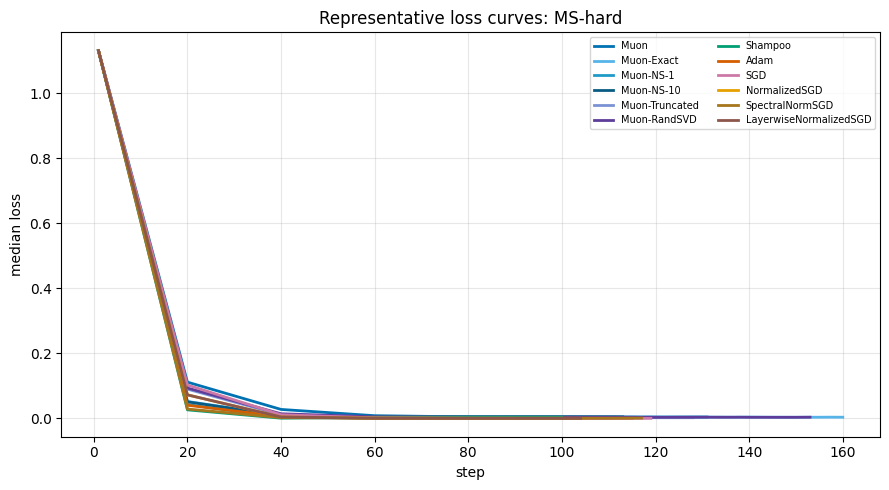

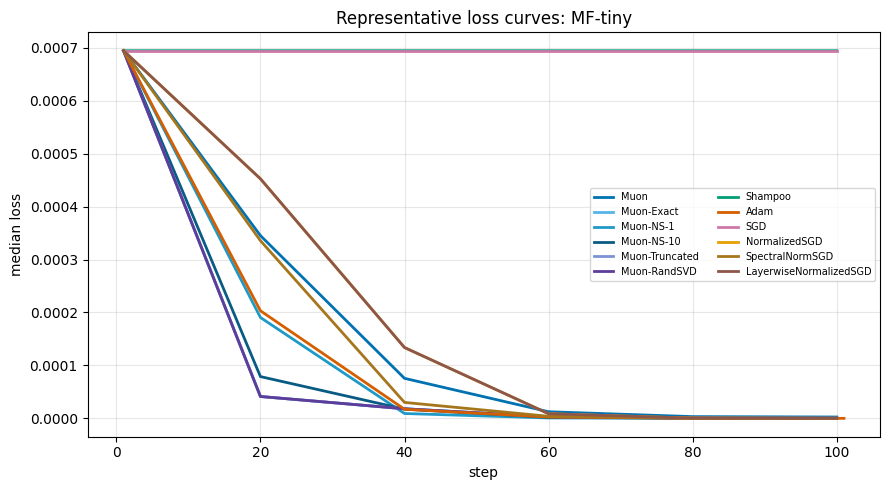

In [11]:
for setting in ["MS-hard", "MF-tiny"]:
    sub = runs[runs["setting"] == setting]
    fig, ax = plt.subplots(figsize=(9.0, 5.0))
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.0, label=algo)
    ax.set_title(f"Representative loss curves: {setting}")
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    show_figure(fig)


### Representative Log-Loss Curves

This is the same Problem-cell variant-dynamics view on a log axis, which is more useful when methods differ by multiplicative loss factors.

This repeats the representative loss curves with a logarithmic loss axis. The visual dimensions are setting, step, method color, and median loss. This is the better version for comparing late-time convergence and small endpoint differences across many variants.

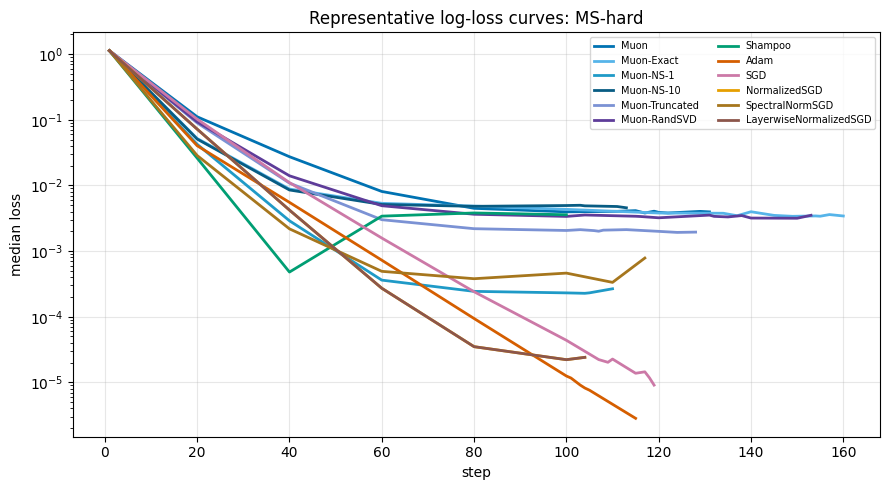

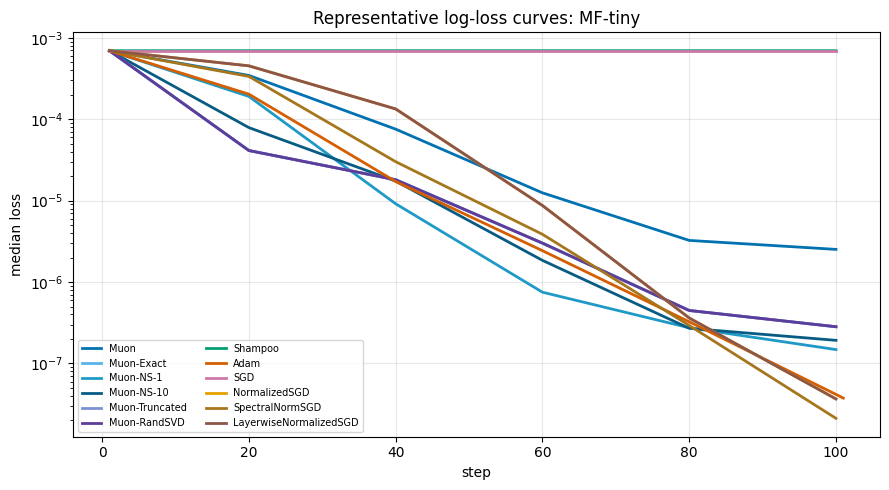

In [12]:
for setting in ["MS-hard", "MF-tiny"]:
    sub = runs[runs["setting"] == setting]
    fig, ax = plt.subplots(figsize=(9.0, 5.0))
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.0, label=algo)
    ax.set_title(f"Representative log-loss curves: {setting}")
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    show_figure(fig)


### Main Table


In [13]:
variant_table = run_summary.groupby(["setting", "algo"], as_index=False, observed=True).agg(
    median_recovery=("relative_matrix_error", "median"),
    median_loss=("final_loss", "median"),
    median_time_per_step=("time_per_step", "median"),
    median_cosine=("grad_update_cosine", "median"),
    median_update_rank=("update_effective_rank", "median"),
    divergence_rate=("diverged", "mean"),
)
IPython.display.display(variant_table)


,setting,algo,median_recovery,median_loss,median_time_per_step,median_cosine,median_update_rank,divergence_rate
0,MF-imbalanced,Adam,0.548110,0.000212,0.000269,0.768360,4.462920,0.0
1,MF-imbalanced,LayerwiseNormalizedSGD,0.688488,0.000332,0.000253,0.280964,3.877669,0.0
2,MF-imbalanced,Muon,0.809838,0.000450,0.000335,0.284222,4.923040,0.0
3,MF-imbalanced,Muon-Exact,0.209117,0.000035,0.000290,0.089388,4.162454,0.0
4,MF-imbalanced,Muon-NS-1,0.395397,0.000112,0.000322,0.101895,3.418873,0.0
...,...,...,...,...,...,...,...,...
91,MS-undersampled,Muon-Truncated,1.233456,0.000517,0.002053,0.397720,23.121997,0.0
92,MS-undersampled,NormalizedSGD,1.045229,0.000082,0.001534,0.946890,48.212781,0.0
93,MS-undersampled,SGD,1.045227,0.000009,0.001526,0.327385,47.923055,0.0
94,MS-undersampled,Shampoo,1.077989,0.012111,0.002166,0.970062,51.752225,0.0


### Reading The Result

If `NormalizedSGD` or `SpectralNormSGD` matches Muon across the hard settings, the main story is update-scale control. If Muon and Muon-Exact beat those baselines while also showing different update effective rank, the polar matrix geometry is contributing beyond scalar normalization.


### Hypothesis Verdict Table

| hypothesis | evidence | supported? | caveat |
|---|---|---|---|
| Muon behavior can be decomposed into polar geometry, approximation quality, and normalization effects. | Exact, Newton-Schulz, truncated, randomized, Frobenius-normalized, spectral-normalized, and layerwise-normalized variants are compared on the same settings. | Yes | The decomposition is empirical and depends on the selected learning rates and implementation costs. |
| Polar geometry should beat normalization-only baselines if it is the main mechanism. | Accuracy-cost and variant tables show where polar variants separate from, match, or lose to normalization baselines. | Partial | No single variant dominates across all Matrix Sensing and Matrix Factorization regimes. |
